# DRAG Pulse Optimization on a Transmon Qubit

This notebook demonstrates the Derivative Removal by Adiabatic Gate (DRAG) technique
for suppressing leakage to the $|2\rangle$ state during fast single-qubit gates on a
superconducting transmon.

**Units:** $\hbar = 1$, frequencies in GHz, times in ns.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from qpulse.transmon import TransmonDRAG
from qpulse.pulses import GaussianPulse, DRAGPulse
from qpulse.metrics import state_populations, leakage, gate_fidelity
from qpulse.optimizer import optimize_beta

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "lines.linewidth": 2,
    "figure.dpi": 120,
})

print("Imports OK")

Imports OK


## 1. System Parameters

In [2]:
# Transmon parameters
OMEGA_Q = 5.0     # GHz — qubit |0⟩→|1⟩ frequency
ALPHA   = -0.3    # GHz — anharmonicity (≈ -E_C/ħ)
N_LEVELS = 3      # Hilbert space truncation

# Gate parameters
# 40 ns keeps Ω_peak/|α| ≈ 0.5, well within the perturbative regime
# where first-order DRAG is effective.
GATE_TIME = 40.0  # ns
N_SIGMA   = 2.0   # Gaussian truncation (±2σ)

# Build the transmon (closed system first)
transmon = TransmonDRAG(
    omega_q=OMEGA_Q,
    alpha=ALPHA,
    n_levels=N_LEVELS,
)

# Verify energy spectrum in rotating frame
# H_0 = (α/2) n(n-1), so E_n = (α/2)n(n-1) in the Fock basis
H0 = transmon._H_static()
H0_dense = H0.full()
print("Rotating-frame energies E_n = (α/2)n(n-1) in Fock basis (GHz):")
for k in range(N_LEVELS):
    E_k = np.real(H0_dense[k, k])
    print(f"  E_{k} = {E_k:+.4f} GHz  ({E_k*1e3:+.1f} MHz)")
print(f"\n  ω_01 (rotating) = {np.real(H0_dense[1,1] - H0_dense[0,0]):.4f} GHz (should be 0)")
print(f"  ω_12 (rotating) = {np.real(H0_dense[2,2] - H0_dense[1,1]):.4f} GHz (should be α = {ALPHA:.4f})")

# Show drive strength ratio
pulse_check = GaussianPulse(gate_time=GATE_TIME, n_sigma=N_SIGMA)
print(f"\n  Peak Ω_I = {pulse_check.amp:.4f} GHz")
print(f"  Ω_peak/|α| = {pulse_check.amp / abs(ALPHA):.2f} (want < 1 for DRAG)")

Rotating-frame energies E_n = (α/2)n(n-1) in Fock basis (GHz):
  E_0 = +0.0000 GHz  (+0.0 MHz)
  E_1 = +0.0000 GHz  (+0.0 MHz)
  E_2 = -0.3000 GHz  (-300.0 MHz)

  ω_01 (rotating) = 0.0000 GHz (should be 0)
  ω_12 (rotating) = -0.3000 GHz (should be α = -0.3000)

  Peak Ω_I = 0.1697 GHz
  Ω_peak/|α| = 0.57 (want < 1 for DRAG)


## 2. Pulse Shape Comparison

Visualize the Gaussian I-channel and the DRAG Q-channel derivative correction.
The Q-channel has spectral weight at the $|1\rangle \leftrightarrow |2\rangle$ detuning
that destructively interferes with leakage.

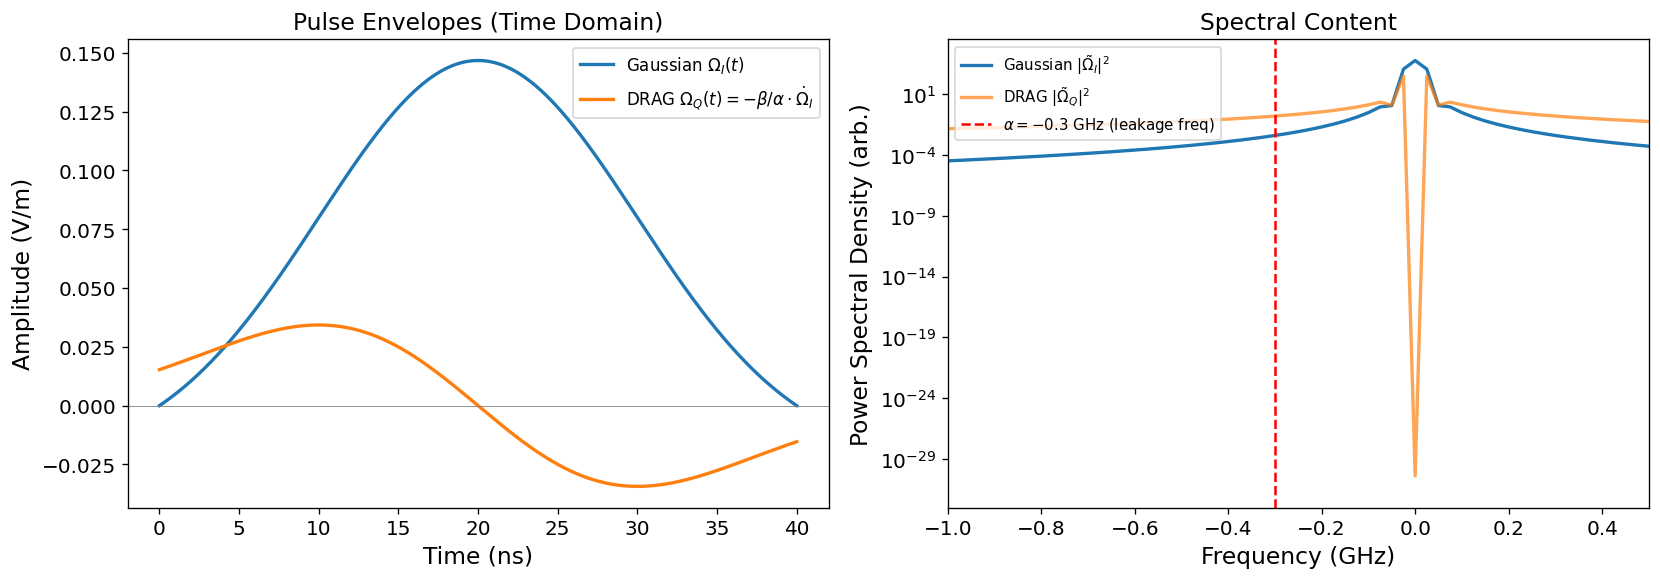

In [4]:
gauss = GaussianPulse(gate_time=GATE_TIME, n_sigma=N_SIGMA)
drag  = DRAGPulse(gate_time=GATE_TIME, beta=1.0, alpha=ALPHA, n_sigma=N_SIGMA)

t = np.linspace(0, GATE_TIME, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Time domain --
ax = axes[0]
ax.plot(t, gauss.I_envelope(t), "C0", label=r"Gaussian $\Omega_I(t)$")
ax.plot(t, drag.Q_envelope(t), "C1", label=r"DRAG $\Omega_Q(t) = -\beta/\alpha \cdot \dot{\Omega}_I$")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Amplitude (V/m)")
ax.set_title("Pulse Envelopes (Time Domain)")
ax.legend(loc="upper right", fontsize=10)

# -- Frequency domain --
ax = axes[1]
dt = t[1] - t[0]
freqs = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))

fft_gauss = np.fft.fftshift(np.fft.fft(gauss.I_envelope(t)))
fft_drag_Q = np.fft.fftshift(np.fft.fft(drag.Q_envelope(t)))

ax.semilogy(freqs, np.abs(fft_gauss)**2, "C0", label=r"Gaussian $|\tilde{\Omega}_I|^2$")
ax.semilogy(freqs, np.abs(fft_drag_Q)**2, "C1", alpha=0.7, label=r"DRAG $|\tilde{\Omega}_Q|^2$")
ax.axvline(ALPHA, color="red", ls="--", lw=1.5, label=rf"$\alpha = {ALPHA}$ GHz (leakage freq)")
ax.set_xlim(-1.0, 0.5)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Power Spectral Density (arb.)")
ax.set_title("Spectral Content")
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
plt.show()

## 3. Population Dynamics: Gaussian vs. DRAG

The key comparison. For a $\pi$-pulse starting from $|0\rangle$:
- **Gaussian only** ($\beta = 0$): leakage to $|2\rangle$ during the pulse
- **DRAG** ($\beta \approx 1$): leakage suppressed by destructive interference

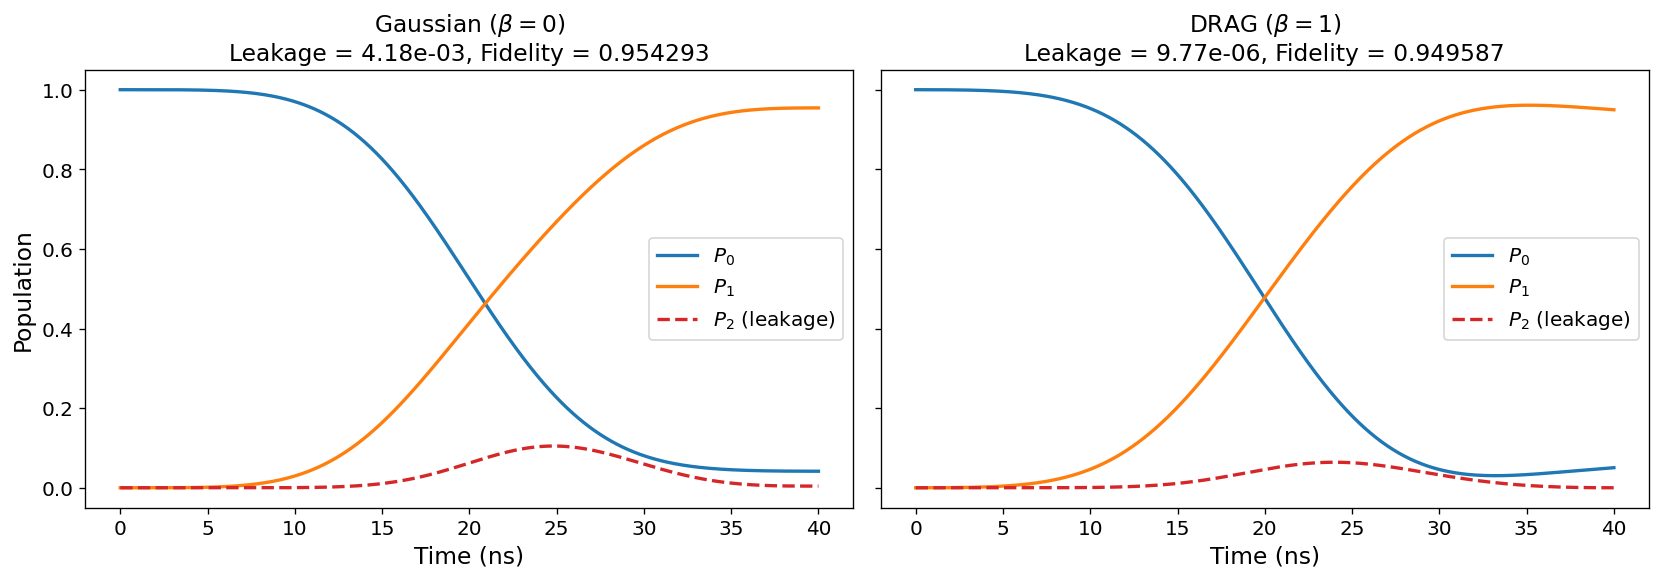

Gaussian — Leakage: 4.1780e-03  Fidelity: 0.954293
DRAG     — Leakage: 9.7711e-06  Fidelity: 0.949587


In [5]:
# Run both simulations
res_gauss = transmon.simulate(gate_time=GATE_TIME, beta=0.0, n_steps=500)
res_drag  = transmon.simulate(gate_time=GATE_TIME, beta=1.0, n_steps=500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, res, title in [
    (axes[0], res_gauss, f"Gaussian ($\\beta = 0$)"),
    (axes[1], res_drag,  f"DRAG ($\\beta = 1$)"),
]:
    pops = state_populations(res, N_LEVELS)
    t_ns = np.array(res.times)

    ax.plot(t_ns, pops["P0"], "C0", label=r"$P_0$")
    ax.plot(t_ns, pops["P1"], "C1", label=r"$P_1$")
    ax.plot(t_ns, pops["P2"], "C3", label=r"$P_2$ (leakage)", ls="--")

    L = leakage(res)
    F = gate_fidelity(res)
    ax.set_title(f"{title}\nLeakage = {L:.2e}, Fidelity = {F:.6f}")
    ax.set_xlabel("Time (ns)")
    ax.legend(loc="center right")

axes[0].set_ylabel("Population")
fig.tight_layout()
plt.show()

print(f"Gaussian \u2014 Leakage: {leakage(res_gauss):.4e}  Fidelity: {gate_fidelity(res_gauss):.6f}")
print(f"DRAG     \u2014 Leakage: {leakage(res_drag):.4e}  Fidelity: {gate_fidelity(res_drag):.6f}")

## 4. $\beta$ Parameter Sweep

Sweep $\beta$ from 0 to 2 to find the optimal DRAG coefficient.
Theory predicts a minimum near $\beta = 1$ for first-order DRAG.

In [ ]:
beta_values = np.linspace(0, 2.0, 60)
sweep = transmon.sweep_beta(gate_time=GATE_TIME, beta_values=beta_values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Leakage vs β
ax1.semilogy(sweep["beta"], sweep["P2"], "C3o-", ms=3, label=r"$P_2(t_f)$ \u2014 leakage")
ax1.set_ylabel(r"Leakage $P_2(t_f)$")
ax1.set_title(rf"$\beta$ Sweep at $t_g = {GATE_TIME:.0f}$ ns, $\alpha/2\pi = {ALPHA*1e3:.0f}$ MHz")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fidelity vs β
ax2.plot(sweep["beta"], sweep["P1"], "C1s-", ms=3, label=r"$P_1(t_f)$ \u2014 fidelity")
ax2.set_xlabel(r"DRAG coefficient $\beta$")
ax2.set_ylabel(r"Fidelity $P_1(t_f)$")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark the optimal β
idx_opt = np.argmin(sweep["P2"])
beta_opt_approx = sweep["beta"][idx_opt]
for ax in (ax1, ax2):
    ax.axvline(beta_opt_approx, color="red", ls=":", lw=1, label=rf"$\beta^* \approx {beta_opt_approx:.2f}$")
    ax.legend()

fig.tight_layout()
plt.show()

print(f"Optimal \u03b2 (grid search): {beta_opt_approx:.3f}")
print(f"  Leakage at optimum: {sweep['P2'][idx_opt]:.4e}")
print(f"  Fidelity at optimum: {sweep['P1'][idx_opt]:.6f}")

## 5. Scipy Optimization of $\beta$

Use `scipy.optimize.minimize_scalar` to find the exact optimum.

In [ ]:
opt_result = optimize_beta(
    transmon,
    gate_time=GATE_TIME,
    bounds=(0.0, 3.0),
    objective="leakage",
)

beta_star = opt_result["beta_opt"]
print(f"Optimized \u03b2* = {beta_star:.6f}")
print(f"Minimum leakage = {opt_result['cost']:.6e}")

# Also optimize for infidelity
opt_fid = optimize_beta(
    transmon,
    gate_time=GATE_TIME,
    bounds=(0.0, 3.0),
    objective="infidelity",
)
print(f"\nOptimized \u03b2* (infidelity) = {opt_fid['beta_opt']:.6f}")
print(f"Minimum infidelity = {opt_fid['cost']:.6e}")

## 6. Optimized DRAG: Final Population Dynamics

In [ ]:
res_opt = transmon.simulate(gate_time=GATE_TIME, beta=beta_star, n_steps=500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

configs = [
    (res_gauss, r"Gaussian ($\beta = 0$)"),
    (res_drag,  r"DRAG ($\beta = 1.0$)"),
    (res_opt,   rf"DRAG ($\beta^* = {beta_star:.3f}$)"),
]

for ax, (res, title) in zip(axes, configs):
    pops = state_populations(res, N_LEVELS)
    t_ns = np.array(res.times)
    ax.plot(t_ns, pops["P0"], "C0", label=r"$P_0$")
    ax.plot(t_ns, pops["P1"], "C1", label=r"$P_1$")
    ax.plot(t_ns, pops["P2"], "C3", ls="--", label=r"$P_2$ (leakage)")
    L = leakage(res)
    F = gate_fidelity(res)
    ax.set_title(f"{title}\nL = {L:.2e}, F = {F:.6f}")
    ax.set_xlabel("Time (ns)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Population")
fig.tight_layout()
plt.show()

## 7. Leakage & Fidelity vs. Gate Time

The speed-fidelity tradeoff: shorter gates drive harder, causing more leakage.
DRAG maintains high fidelity even at aggressive gate times.

In [ ]:
gate_times = np.linspace(10, 80, 30)

sweep_gauss = transmon.sweep_gate_time(gate_times, beta=0.0)
sweep_drag  = transmon.sweep_gate_time(gate_times, beta=beta_star)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Leakage vs gate time
ax1.semilogy(sweep_gauss["gate_time"], sweep_gauss["leakage"], "C0o-", ms=4, label="Gaussian")
ax1.semilogy(sweep_drag["gate_time"],  sweep_drag["leakage"],  "C1s-", ms=4, label=rf"DRAG ($\beta^* = {beta_star:.2f}$)")
ax1.set_ylabel(r"Leakage $P_2(t_f)$")
ax1.set_title(r"Speed\u2013Fidelity Tradeoff: Gaussian vs. DRAG")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fidelity vs gate time
ax2.plot(sweep_gauss["gate_time"], sweep_gauss["fidelity"], "C0o-", ms=4, label="Gaussian")
ax2.plot(sweep_drag["gate_time"],  sweep_drag["fidelity"],  "C1s-", ms=4, label=rf"DRAG ($\beta^* = {beta_star:.2f}$)")
ax2.axhline(0.999, color="gray", ls=":", lw=1, label="99.9% threshold")
ax2.set_xlabel("Gate time (ns)")
ax2.set_ylabel(r"Fidelity $P_1(t_f)$")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Convergence Check: $d = 3$ vs. $d = 4$

Verify that Hilbert space truncation at $d = 3$ is sufficient by comparing with $d = 4$.

In [ ]:
transmon_4 = TransmonDRAG(omega_q=OMEGA_Q, alpha=ALPHA, n_levels=4)

res_3 = transmon.simulate(gate_time=GATE_TIME, beta=beta_star, n_steps=500)
res_4 = transmon_4.simulate(gate_time=GATE_TIME, beta=beta_star, n_steps=500)

fig, ax = plt.subplots(figsize=(10, 5))

t3 = np.array(res_3.times)
t4 = np.array(res_4.times)

for k, (color, ls) in enumerate([("C0", "-"), ("C1", "-"), ("C3", "--")]):
    ax.plot(t3, res_3.expect[k], color=color, ls=ls, label=rf"$P_{k}$, $d=3$")
    ax.plot(t4, res_4.expect[k], color=color, ls=ls, lw=3, alpha=0.3, label=rf"$P_{k}$, $d=4$")

# Show P3 for d=4
ax.plot(t4, res_4.expect[3], "C4", ls=":", label=r"$P_3$, $d=4$")

ax.set_xlabel("Time (ns)")
ax.set_ylabel("Population")
ax.set_title("Convergence Check: Hilbert Space Truncation")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

L3 = leakage(res_3)
L4_comp = 1.0 - res_4.expect[0][-1] - res_4.expect[1][-1]
print(f"Leakage (d=3): {L3:.6e}")
print(f"Leakage (d=4): {L4_comp:.6e}")
print(f"P_3 (d=4):     {res_4.expect[3][-1]:.6e}")

## 9. Open System: T₁/T₂ Effects (Lindblad Master Equation)

Add energy relaxation and dephasing to see how decoherence competes with leakage.

In [ ]:
# T1 = 50 μs = 50000 ns, T2 = 70 μs = 70000 ns
transmon_open = TransmonDRAG(
    omega_q=OMEGA_Q, alpha=ALPHA, n_levels=N_LEVELS,
    t1=50_000.0, t2=70_000.0,
)

res_open_gauss = transmon_open.simulate(gate_time=GATE_TIME, beta=0.0, n_steps=500)
res_open_drag  = transmon_open.simulate(gate_time=GATE_TIME, beta=beta_star, n_steps=500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, res, title in [
    (axes[0], res_open_gauss, r"Gaussian (open, $T_1=50\mu$s)"),
    (axes[1], res_open_drag,  rf"DRAG $\beta^*={beta_star:.2f}$ (open)"),
]:
    pops = state_populations(res, N_LEVELS)
    t_ns = np.array(res.times)
    ax.plot(t_ns, pops["P0"], "C0", label=r"$P_0$")
    ax.plot(t_ns, pops["P1"], "C1", label=r"$P_1$")
    ax.plot(t_ns, pops["P2"], "C3", ls="--", label=r"$P_2$")
    L = leakage(res)
    F = gate_fidelity(res)
    ax.set_title(f"{title}\nL = {L:.2e}, F = {F:.6f}")
    ax.set_xlabel("Time (ns)")
    ax.legend()

axes[0].set_ylabel("Population")
fig.tight_layout()
plt.show()

## 10. Fidelity vs. T₁

Demonstrate that at long coherence times, leakage — not decoherence — is the dominant
error source, which is exactly the regime where DRAG provides its advantage.

In [ ]:
t1_values = np.logspace(3, 5.5, 20)  # 1 μs to ~300 μs in ns
fid_gauss = np.empty_like(t1_values)
fid_drag = np.empty_like(t1_values)

for i, t1_ns in enumerate(t1_values):
    t2_ns = min(2 * t1_ns, 1.4 * t1_ns)  # T2 ≤ 2*T1

    tr_open = TransmonDRAG(
        omega_q=OMEGA_Q, alpha=ALPHA, n_levels=N_LEVELS,
        t1=t1_ns, t2=t2_ns,
    )
    res_g = tr_open.simulate(gate_time=GATE_TIME, beta=0.0, n_steps=200)
    res_d = tr_open.simulate(gate_time=GATE_TIME, beta=beta_star, n_steps=200)
    fid_gauss[i] = gate_fidelity(res_g)
    fid_drag[i] = gate_fidelity(res_d)

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(t1_values / 1e3, 1 - fid_gauss, "C0o-", ms=5, label="Gaussian")
ax.semilogx(t1_values / 1e3, 1 - fid_drag,  "C1s-", ms=5, label=rf"DRAG ($\beta^* = {beta_star:.2f}$)")
ax.set_xlabel(r"$T_1$ ($\mu$s)")
ax.set_ylabel(r"Infidelity $1 - F$")
ax.set_title(r"Gate Infidelity vs. $T_1$ \u2014 Leakage-Limited Regime")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("At long T1, the Gaussian infidelity saturates (leakage-limited),")
print("while DRAG continues to improve, proving leakage is the dominant error.")